# 04 - Classical ML

Random Forest baseline on the engineered pixel features from notebook 03, trained on the original
sen1floods11 `train` split (unchanged, so results stay comparable to every model already in the registry),
tuned via `RandomizedSearchCV`, and evaluated two ways: the original `valid` split (apples-to-apples with
every prior registered version) and this project's own event-holdout `test` split
(`utils/ai/classic/sen1floods11_dataset.load_custom_split()` - see notebook 03 "Custom train/test split" -
`Nigeria`+`Somalia`, entirely unseen during training/tuning, the real generalization number, with a
confusion matrix), with a reference to
[cloudtostreet/Sen1Floods11's own `Train.ipynb`](https://github.com/cloudtostreet/Sen1Floods11/blob/master/Train.ipynb)
below. Random Forest instead of the U-Net (also implemented, `utils/ai/classic/unet.py`) here specifically
because it trains on real per-pixel data in seconds-to-minutes on CPU - this notebook is meant to run
end-to-end without a GPU and give a real number to compare the quantum kernel model (05) against, not to
be the final production segmentation model.

In [1]:
import os
import sys

# Portable project-root resolution (no machine-specific hardcoded path) -
# walk up from the current working directory until pyproject.toml is found.
# One statement on purpose: ruff/pycodestyle's E402 ("imports not at top")
# specifically exempts a lone sys.path.insert(...) call, not a multi-
# statement block before it.
sys.path.insert(0, next(
    d for d in (
        os.path.abspath(os.path.join(os.getcwd(), *([os.pardir] * i)))
        for i in range(8)
    )
    if os.path.exists(os.path.join(d, "pyproject.toml"))
))

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

from utils.ai.classic.sen1floods11_dataset import (
    chip_id_from_s1_filename,
    load_custom_split,
    load_split,
    read_label,
    read_s1,
)
from utils.ai.objectives.registry import evaluate
from utils.fusion.pixel_features import build_feature_cube, cube_to_pixel_table
from utils.observability.run_logger import RunLogger

_root = sys.path[0]
logger = RunLogger("04_classical_ml")
RNG = np.random.default_rng(42)
REPORTS_DIR = os.path.join(_root, "datasets", "reports")

## Build pixel tables from multiple chips

Uses a subsample of chips (not the full 252-chip train split) to keep this runnable in a reasonable time
on CPU - real data, real training, just bounded scope. Increase `N_TRAIN_CHIPS`/`N_VALID_CHIPS` for a
fuller run. Train/valid use the original sen1floods11 split (unchanged from the pre-tuning baseline, so
`valid_*` metrics below isolate the effect of tuning, not a training-distribution change); test uses this
project's own event-holdout split (notebook 03) - see per-table comments below.

In [2]:
N_TRAIN_CHIPS = 20
N_VALID_CHIPS = 8
N_TEST_CHIPS = 44  # small enough to just use every custom-test chip (event holdout, see notebook 03)

def build_pixel_dataset(pairs: list[tuple[str, str]], n_chips: int, seed: int = 0):
    rng = np.random.default_rng(seed)
    chosen = rng.choice(len(pairs), size=min(n_chips, len(pairs)), replace=False)

    xs, ys = [], []
    for idx in chosen:
        s1_filename, _ = pairs[idx]
        chip_id = chip_id_from_s1_filename(s1_filename)
        s1 = read_s1(chip_id)
        label = read_label(chip_id)
        cube = build_feature_cube(s1)
        x, y = cube_to_pixel_table(cube, label, raw_s1=s1)
        xs.append(x); ys.append(y)
    return np.concatenate(xs), np.concatenate(ys)

In [3]:
with logger.stage("build_train_pixel_table") as stage:
    # Original sen1floods11 train split, unchanged from the pre-tuning baseline - isolates hyperparameter
    # tuning as the only variable vs. that baseline (a different training chip sample would confound the
    # "valid_*" comparison below with a training-distribution shift, not just a hyperparameter change).
    x_train, y_train = build_pixel_dataset(load_split("train"), N_TRAIN_CHIPS, seed=1)
    stage.metrics = {"n_chips": N_TRAIN_CHIPS, "n_pixels": int(len(y_train)), "split_source": "default_train"}

with logger.stage("build_valid_pixel_table") as stage:
    # Original sen1floods11 valid split, unchanged - kept so "valid_*" metrics below stay comparable
    # across every run already in the registry/Compare page.
    x_valid, y_valid = build_pixel_dataset(load_split("valid"), N_VALID_CHIPS, seed=2)
    stage.metrics = {"n_chips": N_VALID_CHIPS, "n_pixels": int(len(y_valid)), "split_source": "default_valid"}

with logger.stage("build_test_pixel_table") as stage:
    # This project's own event-holdout test (Nigeria + Somalia, notebook 03) - never seen during
    # training or hyperparameter search below, the real generalization check.
    x_test, y_test = build_pixel_dataset(load_custom_split("test"), N_TEST_CHIPS, seed=3)
    stage.metrics = {"n_chips": N_TEST_CHIPS, "n_pixels": int(len(y_test)), "split_source": "custom_test"}

print(f"train: {x_train.shape}, valid: {x_valid.shape}, test (event holdout): {x_test.shape}")

[04_classical_ml] -> build_train_pixel_table ...


[04_classical_ml] <- build_train_pixel_table [OK] 0.987s {'n_chips': 20, 'n_pixels': 4456397, 'split_source': 'default_train'}
[04_classical_ml] -> build_valid_pixel_table ...


[04_classical_ml] <- build_valid_pixel_table [OK] 0.323s {'n_chips': 8, 'n_pixels': 1578750, 'split_source': 'default_valid'}
[04_classical_ml] -> build_test_pixel_table ...


[04_classical_ml] <- build_test_pixel_table [OK] 1.747s {'n_chips': 44, 'n_pixels': 9394609, 'split_source': 'custom_test'}
train: (4456397, 6), valid: (1578750, 6), test (event holdout): (9394609, 6)


## Hyperparameter tuning

`RandomizedSearchCV` over `n_estimators` / `max_depth` / `min_samples_leaf` / `max_features`, scored on F1
(more sensitive to the minority `water` class than accuracy on this ~1-6% water-fraction dataset - see
notebook 03's EDA). Searched on a 150k-pixel random subsample of `x_train` (not the full table) - pixel
rows within a chip are highly spatially correlated, so subsampling rows for the *search* phase only is a
standard, defensible way to keep `n_iter x cv` candidate fits tractable on CPU; the winning hyperparameters
are then refit on the *full* `x_train` table in the next cell, same approach cloudtostreet's own
[`Train.ipynb`](https://github.com/cloudtostreet/Sen1Floods11/blob/master/Train.ipynb) takes to hyperparameter
selection (search cheap, refit full).

In [4]:
with logger.stage("hyperparameter_search") as stage:
    SEARCH_SAMPLE_SIZE = min(150_000, len(y_train))
    search_idx = RNG.choice(len(y_train), size=SEARCH_SAMPLE_SIZE, replace=False)
    x_search, y_search = x_train[search_idx], y_train[search_idx]

    # max_depth intentionally excludes None (unbounded) - a first pass with it included picked
    # max_depth=None on the 150k-row search sample (looked good in CV there) but, refit on the full
    # ~4.7M-row train table, grew a >2GB pickle and *overfit* (valid_iou dropped to 0.19 from a 0.36
    # baseline) - pixel rows within a chip are highly spatially correlated, so unbounded trees can
    # nearly memorize per-chip texture rather than generalize. Capped depths regularize against exactly
    # that, at a fraction of the storage/inference cost.
    param_distributions = {
        "n_estimators": [50, 100, 150, 200],
        "max_depth": [8, 10, 12, 16, 20],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5],
    }
    # RF n_jobs=1 + search n_jobs=-1 (not the other way around): lets sklearn parallelize across the
    # n_iter*cv candidate fits themselves, avoiding nested-parallelism oversubscription on this box's cores.
    search = RandomizedSearchCV(
        RandomForestClassifier(n_jobs=1, random_state=42),
        param_distributions=param_distributions,
        n_iter=8,
        cv=3,
        scoring="f1",
        random_state=42,
        n_jobs=-1,
    )
    search.fit(x_search, y_search)
    stage.metrics = {
        "search_sample_size": SEARCH_SAMPLE_SIZE,
        "n_candidates": 8,
        "cv_folds": 3,
        "best_cv_f1": round(float(search.best_score_), 4),
    }

print("best hyperparameters (RandomizedSearchCV, F1 on a 150k-pixel subsample, cv=3):")
for k, v in search.best_params_.items():
    print(f"  {k:16s} {v}")
print(f"best CV F1: {search.best_score_:.4f}")

[04_classical_ml] -> hyperparameter_search ...


[04_classical_ml] <- hyperparameter_search [OK] 197.904s {'search_sample_size': 150000, 'n_candidates': 8, 'cv_folds': 3, 'best_cv_f1': 0.605}
best hyperparameters (RandomizedSearchCV, F1 on a 150k-pixel subsample, cv=3):
  n_estimators     50
  min_samples_leaf 4
  max_features     0.5
  max_depth        10
best CV F1: 0.6050


## Final fit (full train table, tuned hyperparameters) + evaluation

In [5]:
with logger.stage("train_random_forest") as stage:
    clf = RandomForestClassifier(**search.best_params_, n_jobs=-1, random_state=42)
    clf.fit(x_train, y_train)
    stage.metrics = {**search.best_params_, "n_train_pixels": int(len(y_train))}

with logger.stage("evaluate_random_forest") as stage:
    # Original sen1floods11 valid split - "valid_*" metrics below stay comparable to every prior
    # registered version (they were all evaluated against this same split).
    y_pred = clf.predict(x_valid)
    metrics = evaluate("flood-segmentation", y_pred, y_valid)
    stage.metrics = {k: round(v, 4) for k, v in metrics.items()}

print("Random Forest metrics on the original sen1floods11 valid split:")
for k, v in metrics.items():
    print(f"  {k:12s} {v:.4f}")

[04_classical_ml] -> train_random_forest ...


[04_classical_ml] <- train_random_forest [OK] 364.706s {'n_estimators': 50, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 10, 'n_train_pixels': 4456397}
[04_classical_ml] -> evaluate_random_forest ...


[04_classical_ml] <- evaluate_random_forest [OK] 1.633s {'iou': 0.1303, 'f1': 0.2305, 'precision': 0.6731, 'recall': 0.1391, 'boundary_f1': 0.2015}
Random Forest metrics on the original sen1floods11 valid split:
  iou          0.1303
  f1           0.2305
  precision    0.6731
  recall       0.1391
  boundary_f1  0.2015


## Event-holdout test + confusion matrix

The real generalization check: `Nigeria` and `Somalia` were held out entirely from `train`/`valid`/the
hyperparameter search above (notebook 03), so this is genuinely unseen-event performance, not just
unseen-chip. Confusion matrix in raw pixel counts, same two classes the rest of the platform uses
(`not_water`=0, `water`=1 - see `config/platform.yaml`'s `objectives.flood-segmentation`).

[04_classical_ml] -> evaluate_random_forest_event_holdout ...


[04_classical_ml] <- evaluate_random_forest_event_holdout [OK] 9.673s {'iou': 0.4272, 'f1': 0.5986, 'precision': 0.8508, 'recall': 0.4618, 'boundary_f1': 0.1745}
Random Forest metrics on this project's own event-holdout test split (Nigeria + Somalia, unseen):
  iou          0.4272
  f1           0.5986
  precision    0.8508
  recall       0.4618
  boundary_f1  0.1745


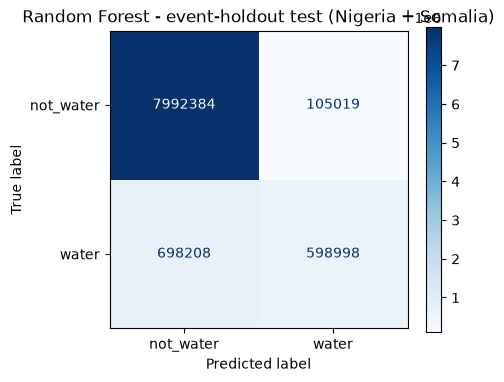

saved -> D:\project-raw-data\sphoorthq-geoverse\datasets\reports\04_confusion_matrix.png
[[7992384  105019]
 [ 698208  598998]]


In [6]:
with logger.stage("evaluate_random_forest_event_holdout") as stage:
    y_pred_test = clf.predict(x_test)
    test_metrics = evaluate("flood-segmentation", y_pred_test, y_test)
    stage.metrics = {k: round(v, 4) for k, v in test_metrics.items()}

print("Random Forest metrics on this project's own event-holdout test split (Nigeria + Somalia, unseen):")
for k, v in test_metrics.items():
    print(f"  {k:12s} {v:.4f}")

cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["not_water", "water"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Random Forest - event-holdout test (Nigeria + Somalia)")
plt.tight_layout()
cm_path = os.path.join(REPORTS_DIR, "04_confusion_matrix.png")
plt.savefig(cm_path, dpi=110)
plt.show()
print(f"saved -> {cm_path}")
print(cm)

In [7]:
import pickle

MODEL_PATH = os.path.join(_root, "datasets", "processed", "models", "classical_rf_v1.pkl")

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
with open(MODEL_PATH, "wb") as f:
    pickle.dump(clf, f)

logger.log_metrics({
    "model_path": MODEL_PATH,
    "best_hyperparameters": search.best_params_,
    **{f"valid_{k}": v for k, v in metrics.items()},
    **{f"test_{k}": v for k, v in test_metrics.items()},
})
logger.finalize()
print(f"saved model -> {MODEL_PATH}")

[04_classical_ml] run complete in 578.125s -> D:\project-raw-data\sphoorthq-geoverse\datasets\reports\runs\f178fd75-77f3-4885-bf87-e87fa0e1a7c5.json
saved model -> D:\project-raw-data\sphoorthq-geoverse\datasets\processed\models\classical_rf_v1.pkl
